# Export your design to GDS

> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.4 Headless quick view](../1-Overview/1.4-Headless-quick-view-%28no-Qt-GUI%29.ipynb) for a complete runnable walkthrough and [`docs/headless-usage.rst`](../../docs/headless-usage.rst) for the full reference.

For convenience, let's begin by enabling [automatic reloading of modules](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) when they change.

## Will export_to_gds() add to my GDS file?   
Most likely, yes!

The cells below describe what is in an exported gds file. Geometries that an user wants to add for a component, can be put on a layer chosen by user. What export_to_gds does in the background is not finalized and will most likely be changed, based on a format, that is usable by multiple types of users.  Layers represent manufacturing intention, thus proprietary information, which cannot be published outside scientific papers or fab-customer relationships. While on our roadmap, we have the enablement, of a techfile-driven setup for layers. 

In [1]:
%load_ext autoreload
%autoreload 2

### Import Qiskit Metal

In [2]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross

10:49PM 13s WARNING [_maybe_warn_lite_flip]: [FutureWarning] quantum-metal v0.7.0 will move PySide6, qdarkstyle, pyaedt, pyEPR-quantum, and gmsh out of base dependencies into opt-in extras. To preserve the current v0.6.x install behaviour, run `pip install 'quantum-metal[full]'` before upgrading. See ROADMAP.md and docs/migration-to-v0.7.0.rst for details. Set QISKIT_METAL_SUPPRESS_LITE_FLIP_WARNING=1 to silence.


In [3]:
design = designs.DesignPlanar()
gui = MetalGUI(design)

In [4]:
design.overwrite_enabled = True
design.delete_all_components()
gui.rebuild()  # refresh

In [5]:
Headings.h1("Populate QDesign to demonstrate exporting to GDS format.")

In [6]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Allow running the same cell here multiple times to overwrite changes.
design.overwrite_enabled = True

## Custom options for all the transmons.
options = dict(
    # Some options we want to modify from the defaults.
    # (see below for defaults)
    pad_gap="80 um",
    pad_width="425 um",
    pocket_height="650um",
    # Adding 4 connectors (see below for defaults)
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

## Note repeated from "Introduction to QRenderers.ipynb":  
The cell name denoted by, "gds_cell_name" will be the selected cell   
from design.renderers.gds.options['path_filename']   
when design.renderers.gds.export_to_gds() is executed.

In [7]:
## Create 4 TransmonPockets

# For variety and demonstartion, use different gds_cell_names.
q1 = TransmonPocket(
    design,
    "Q1",
    options=dict(
        pos_x="+2.55mm", pos_y="+0.0mm", gds_cell_name="FakeJunction_02", **options
    ),
)
q2 = TransmonPocket(
    design,
    "Q2",
    options=dict(
        pos_x="+0.0mm",
        pos_y="-0.9mm",
        orientation="90",
        gds_cell_name="FakeJunction_01",
        **options,
    ),
)
q3 = TransmonPocket(
    design,
    "Q3",
    options=dict(
        pos_x="-2.55mm", pos_y="+0.0mm", gds_cell_name="FakeJunction_01", **options
    ),
)
q4 = TransmonPocket(
    design,
    "Q4",
    options=dict(
        pos_x="+0.0mm",
        pos_y="+0.9mm",
        orientation="90",
        gds_cell_name="my_other_junction",
        **options,
    ),
)

## Rebuild the design
gui.rebuild()
gui.autoscale()

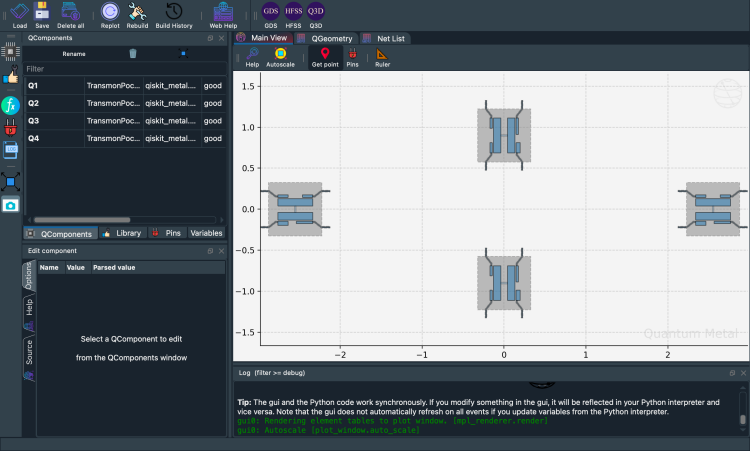

In [8]:
gui.screenshot()

## Connecting QPins with coplanar waveguides (CPWs) as described in earlier notebooks.

In [9]:
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

RouteMeander.get_template_options(design)

options = Dict(meander=Dict(lead_start="0.1mm", lead_end="0.1mm", asymmetry="0 um"))


def connect(
    component_name: str,
    component1: str,
    pin1: str,
    component2: str,
    pin2: str,
    length: str,
    asymmetry="0 um",
    flip=False,
    fillet="50um",
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        fillet=fillet,
        pin_inputs=Dict(
            start_pin=Dict(component=component1, pin=pin1),
            end_pin=Dict(component=component2, pin=pin2),
        ),
        lead=Dict(start_straight="0.13mm", end_straight="0.13mm"),
        total_length=length,
    )
    myoptions.update(options)
    myoptions.meander.asymmetry = asymmetry
    myoptions.meander.lead_direction_inverted = "true" if flip else "false"
    return RouteMeander(design, component_name, myoptions)


asym = 90

# For variety in output, use different fillet values.
cpw1 = connect("cpw1", "Q1", "d", "Q2", "c", "5.7 mm", f"+{asym}um", fillet="25um")
cpw2 = connect(
    "cpw2", "Q3", "c", "Q2", "a", "5.4 mm", f"-{asym}um", flip=True, fillet="100um"
)
cpw3 = connect("cpw3", "Q3", "a", "Q4", "b", "5.3 mm", f"+{asym}um", fillet="75um")
cpw4 = connect("cpw4", "Q1", "b", "Q4", "d", "5.5 mm", f"-{asym}um", flip=True)

gui.rebuild()
gui.autoscale()

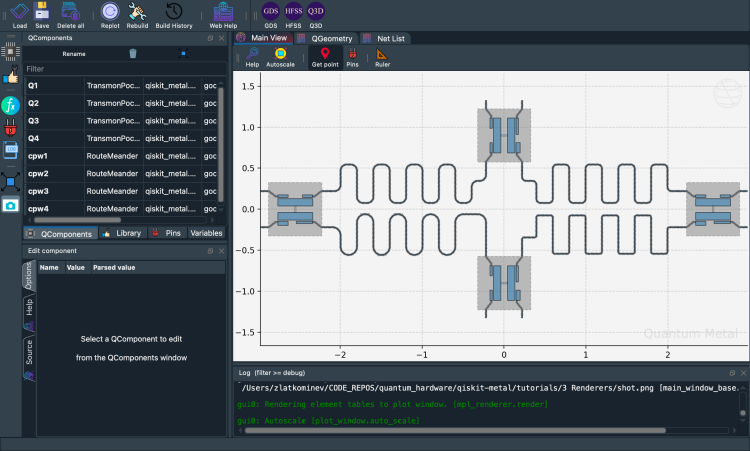

In [10]:
gui.screenshot()

In [11]:
Headings.h1("Exporting to a GDS file.")

In [12]:
# QDesign registers GDS renderer during init of QDesign.
a_gds = design.renderers.gds
# An alternate way to invoke gds commands without using a_gds:
# design.renderers.gds.export_to_gds()

# Show the options for GDS
a_gds.options

{'short_segments_to_not_fillet': 'True',
 'check_short_segments_by_scaling_fillet': '2.0',
 'gds_unit': 0.001,
 'ground_plane': 'True',
 'negative_mask': {'main': []},
 'fabricate': 'False',
 'corners': 'natural',
 'tolerance': '0.00001',
 'precision': '0.000000001',
 'width_LineString': '10um',
 'path_filename': '../resources/Fake_Junctions.GDS',
 'junction_pad_overlap': '5um',
 'max_points': '199',
 'cheese': {'datatype': '100',
  'shape': '0',
  'cheese_0_x': '25um',
  'cheese_0_y': '25um',
  'cheese_1_radius': '100um',
  'view_in_file': {'main': {1: True}},
  'delta_x': '100um',
  'delta_y': '100um',
  'edge_nocheese': '200um'},
 'no_cheese': {'datatype': '99',
  'buffer': '25um',
  'cap_style': '2',
  'join_style': '2',
  'view_in_file': {'main': {1: True}}},
 'bounding_box_scale_x': '1.2',
 'bounding_box_scale_y': '1.2'}

## Will export_to_gds() add datatype for Polygon and Flexpath to my GDS file. 
Yes.  If you see a datatype being added to your positive mask, datatype=10 means a Polygon was added to the layer, datatype=11 means Flexpath was added to the layer.   However, `for each layer` that has a negative mask, due to boolean subtract command done by export_to_gds, the 10 and 11 datatypes will not be in the gds file.

For positive mask, datatype=0 is for the ground plane. 

##  To make `junction table` work correctly, GDS Renderer needs a correct path to a gds file, which has cells.  
Each cell is a junction, to be placed, in a Transmon.  A sample gds file is provided in directory `qiskit_metal/tutorials/resources`.
There are three cells with names "Fake_Junction_01", "Fake_Junction_01", and "my_other_junction".
The default name used by GDS Render is "my_other_junction".  If you want to customize and select a junction, through the QComponent's options, you can pass it when a qcomponent is being added to QDesign. 

## If your added junctions to a qcomponent.

The junctions are imported from file at gds.options.path_filename.  The cell from path_filename which is denoted by TransmonPocket.options.gds_cell_name is imported and placed at location determined by the qcomponent developer.  The method export_to_gds will place the imported cell at the same layers which are identified in the file at gds.options.path_filename.

In [13]:
a_gds.options["path_filename"] = "../resources/Fake_Junctions.GDS"

Do you want GDS Renderer to fix any short-segments in your QDesign when using fillet?'



In [14]:
# If you have a fillet_value and there are LineSegments that are shorter than 2*fillet_value,
# When true, the short segments will not be fillet'd.
a_gds.options["short_segments_to_not_fillet"] = "False"

In [15]:
scale_fillet = 2.0
a_gds.options["check_short_segments_by_scaling_fillet"] = scale_fillet

## What criteria will be used for identifying a short segment?
If a segment is smaller than (fillet length *  scale_fillet)

## What if a segment of LineString has few short segments?  
If option 'short_segments_to_not_fillet' == 'True', QGDSRenderer will
break the LineString into shorter Linestrings to make smaller LineStrings that will be 
either fillet'd or not, based on if the segment is short.

In [18]:
# If you want to have the short segments not be fillet'd.
a_gds.options["short_segments_to_not_fillet"] = "True"

In [19]:
# Export to a GDS formatted file for all components in design.
# def export_to_gds(self, file_name: str, highlight_qcomponents: list = []) -> int:

a_gds.export_to_gds("GDS QRenderer Notebook.gds")
# You can also specify a different path. Example:
#   a_gds.export_to_gds("../../../gds-files/GDS QRenderer Notebook.gds")

10:53PM 53s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [20]:
# Export a GDS file which contains only few components.

# You will probably want to put the exported file in a specific directory.
# Please give the full path for output.
a_gds.export_to_gds(
    "four_qcomponents.gds", highlight_qcomponents=["cpw1", "cpw4", "Q1", "Q3"]
)

10:54PM 00s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [21]:
# Export a GDS file using explicit path and cpw1.name vs typing string.
# You will probably want to put the exported file in a specific directory.
# Please give the full path for output.
a_gds.export_to_gds(
    "four_same_qcomponents.gds",
    highlight_qcomponents=[cpw1.name, "cpw4", q1.name, "Q3"],
)

10:54PM 04s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [22]:
Headings.h1("QUESTION:  Where is the geometry of a QComponent placed?")

## Answer:  QGeometry tables!

This is better explained in folder "2 Front End User/2.4 QRenderer Introduction" in notebook, "QRenderer Introduction ".

In [23]:
Headings.h1('What does GDS do with "junction" table?')

The junction table is handled differently by each QRenderer.

GDS QRenderer gets a cell, with the name, equal to "gds_cell_name" and places the cell into the QDesign before exporting the entire QDesign to GDS. In file: `a_gds.options['path_filename'] = '../resources/Fake_Junctions.GDS'`, the gds_cell_name is searched.  The cell is placed into QDesign using LINESTRING and width information.

The cell within "path_filename", should be "x-axis" aligned and then GDS rotates based on LineString.  The LineString should be two vertexes and it denotes two things.
1. The midpoint of segment is the center of cell. 
2. The angle made by (second tuple - fist tuple), for delta y/ delta x, is used to rotate the cell. 

When the cell from default_options.path_filename does not fit the width of LineString,
- QGDSRender will create two pads and add to cell, which is denoted in junction table, to fill the width of LineString. The length of the additional pads is the value of "width" from the junction table. 
- The option `a_gds.options["junction_pad_overlap"]='5um'` is the amount the new pads will overlap the cell. The final width of the cell plus two pads is equal to the magnitude of LineString. 

In [24]:
# View every entry in junction table.
design.qgeometry.tables["junction"]

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (2.55 -0.04, 2.55 0.04)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_02,1.000000e-08,0,1.000000e-08,0
1,2,rect_jj,"LINESTRING (0.04 -0.9, -0.04 -0.9)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
2,3,rect_jj,"LINESTRING (-2.55 -0.04, -2.55 0.04)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
3,4,rect_jj,"LINESTRING (0.04 0.9, -0.04 0.9)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [25]:
# View the juction table for component "q1".

q1.qgeometry_table("junction")

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (2.55 -0.04, 2.55 0.04)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_02,1.000000e-08,0,1.000000e-08,0


## Geometric boundary of a QComponent?
How to obtain the boundary box of the geometry, for example: `q1.qgeometry_bounds()`.  
Explained in in folder "2 Front End User/2.4 QRenderer Introduction" in notebook, "QRenderer Introduction ".

In [26]:
# The current value of all the options for GDS QRenderer.
a_gds.options

{'short_segments_to_not_fillet': 'True',
 'check_short_segments_by_scaling_fillet': 2.0,
 'gds_unit': 0.001,
 'ground_plane': 'True',
 'negative_mask': {'main': []},
 'fabricate': 'False',
 'corners': 'natural',
 'tolerance': '0.00001',
 'precision': '0.000000001',
 'width_LineString': '10um',
 'path_filename': '../resources/Fake_Junctions.GDS',
 'junction_pad_overlap': '5um',
 'max_points': '199',
 'cheese': {'datatype': '100',
  'shape': '0',
  'cheese_0_x': '25um',
  'cheese_0_y': '25um',
  'cheese_1_radius': '100um',
  'view_in_file': {'main': {1: True}},
  'delta_x': '100um',
  'delta_y': '100um',
  'edge_nocheese': '200um'},
 'no_cheese': {'datatype': '99',
  'buffer': '25um',
  'cap_style': '2',
  'join_style': '2',
  'view_in_file': {'main': {1: True}}},
 'bounding_box_scale_x': '1.2',
 'bounding_box_scale_y': '1.2'}

## Number of vertices for linestrings.
The option max_points has default of 199.  You can set it to a number no higher than 8191.

In [27]:
### For demo, set max_points to 8191 and look at the GDS output.
a_gds.options["max_points"] = "8191"
a_gds.export_to_gds("GDS QRenderer Notebook maxpoints8191.gds")

10:54PM 12s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

## Changing options 'precision' vs 'tolerance' ratio can impact how fillet will look.

The below numbers are used to create a gdstk.FlexPath when 
there is a fillet value in QGeometry table.

bend_radius – Bend radii for each path when corners is ‘circular bend’. 
It has no effect for other corner types.  QGDSRender uses 'circular bend' as a default for corners.
The fillet value used here.

Ensure that tolerance > precision.

tolerance (number) – Tolerance used to draw the paths and calculate joins.

precision (number) – Precision for rounding the coordinates of vertices when fracturing the final polygonal boundary.


In [28]:
# Restore previous example.
a_gds.options["max_points"] = "199"

# For Demo, change tolerance value.
a_gds.options["tolerance"] = "0.01"
# This exported file will not look as desired.
a_gds.export_to_gds("GDS QRenderer Notebook change tolerance.gds")

10:54PM 13s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [29]:
# change it back to was it was.
a_gds.options["tolerance"] = "0.00001"

In [30]:
Headings.h1("Layer numbers: cheese and mask")

## What can I control by layer number?  

* positive mask
* negative mask
* cheese
* no_cheese



## If you wanted cheese or no_cheese in the GDS file.


The reason you choose to use cheesing is up to the developer.   There are considerations for both manufacturing and EM design.  This refers to the holes in the output GDS ground plane (cheese = holes). From an EM stand-point https://www.degruyter.com/document/doi/10.1515/psr-2017-8000/html.

Cheesing refers to the holes added to the chip. The “cheese” output will correspond to the mask (positive or negative) selected.  Both cheese and no_cheese output can be generated for any layer.  You can choose to add the no_cheese to the exported GDS file; adding no_cheese information in GDS file, is just to show the intermediate step.

In the cheese dict, edge_nocheese option denotes a buffer around the perimeter of the chip.  You can identify which layer has the cheesing by using the key view_in_file.  To identify a datatype to store the geometry for cheesing, edit the key named datatype. 

The option no_cheese can be thought of as a “keep-out” region for cheesing.  Based on the components on the chip, a no-cheese region is determined.  The no_cheese region is created by adding a buffer around all the components.   In no_cheese dict, there is a key called buffer, that denotes the size around all the components for no_cheese.  Even if view_in_file may be True for cheese dict, user can make it false for no_cheese dict.  If the user wants to view the no_cheese region in the GDS output, keep it as True for each layer you are interested it.  

The location of cheesing is determined by
1. generating a grid of holes for the size of chip
2. subtract the no_cheese region
3. subtract the edge_nocheese region


The method export_to_gds, uses the datatype in cheese dict, default is 100, and no_cheese dict, default is 99; then uses few extra datatypes by adding one or two.   The extra datatypes are to show some intermediate steps.  If you choose to view_in_file, then you will see cheese or no-cheese in the gds file.  

TOP_chipname_layernumber_one_hole is a cell with just one hole.  The rest of the holes are made as a reference from the one hole.  The hole is placed with datatype_cheese+2.  This is expected to change when we agree to some convention. 

TOP_chipname_layernumber_NoCheese_datatype is a cell that holds the “keep-out” region for cheesing.  

TOP_chipname_layernumber_Cheese_datatype is a cell that holds the cheesing region.  

TOP_chipname_layernumber holds the geometry taken from Metal GUI.   



TOP_chipname_layernumber_Cheese_diff is a cell that holds the difference between grid of holes on chip, minus the no_cheese region.  It is placed in datatype_cheese+1.  This is expected to change when we agree to some convention. 

`For negative mask`:
TOP_chipname_layernumber_Cheese_diff is placed under TOP_chipname_layernumber.  


`For positive mask`:
TOP_chipname_layernumber_Cheese_diff is subtracted from ground and placed under TOP_chipname_layernumber. 





## Changing Cheesing options
There are two dicts in default_options for cheesing.  One for selecting the no_cheese (keep-out region) for cheesing, the other for cheesing.  Use them to determine if you would like the cheesing cell and the no_cheese cell to be added to the GDS file.

To create the no-cheese region, we take the existing components and add a buffer around the perimeter.  The size of the buffer is an option.  

The output of the cells can be placed with a data type.  The user can select a different data type for both the no-cheese region and the cheese region.

Regarding the cheese option, there is room for expansion, presently, the shape that available for a hole is a shape=0, which is a square.  

The present placement of holes allows the user to apply edge_nocheese to the perimeter of the chip.  This allows the user to place holes at a perimeter smaller than the chip size.   Then a grid of holes is made using delta_x and delta_y. 


In [31]:
a_gds.options.no_cheese

{'datatype': '99',
 'buffer': '25um',
 'cap_style': '2',
 'join_style': '2',
 'view_in_file': {'main': {1: True}}}

In [32]:
a_gds.options.cheese

{'datatype': '100',
 'shape': '0',
 'cheese_0_x': '25um',
 'cheese_0_y': '25um',
 'cheese_1_radius': '100um',
 'view_in_file': {'main': {1: True}},
 'delta_x': '100um',
 'delta_y': '100um',
 'edge_nocheese': '200um'}

There is a dict option called view_in_file that denotes if the cells are added to GDS file.  The first sub-option is the chip name, the second sub-option is layer number, the third sub-option is  bool True/False. 

In our example, the chip is 'main' and the layer is 1.  We allow for expansion for multiple chips, and multiple ground layers. 


In [33]:
a_gds.options["cheese"]["view_in_file"]["main"][1] = True
a_gds.options["no_cheese"]["view_in_file"]["main"][1] = True
a_gds.export_to_gds("GDS QRender_cheese_keepout.gds")

10:54PM 15s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [34]:
a_gds.options["cheese"]["view_in_file"]["main"][1] = True
a_gds.options["no_cheese"]["view_in_file"]["main"][1] = False
a_gds.export_to_gds("GDS QRender_cheese_only.gds")

10:54PM 16s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [35]:
# For example, just move the cpws to layer=14.
cpw1.options.layer = 14
cpw2.options.layer = 14
cpw3.options.layer = 14
cpw4.options.layer = 14

In [36]:
gui.rebuild()

# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()
gui.zoom_on_components(all_component_names)

In [37]:
# Turn on/off keep-out and cheesing.
a_gds.options["cheese"]["view_in_file"]["main"][1] = True
a_gds.options["no_cheese"]["view_in_file"]["main"][1] = True
a_gds.options["cheese"]["view_in_file"]["main"][14] = True
a_gds.options["no_cheese"]["view_in_file"]["main"][14] = True

## If you want a positive and/or negative masks.  

User can request a positive or negative mask by chip-name and layer-number.  The default is to use a positive mask.  If user wants to use a negative mask, then just identify the layers that should be a negative mask.  The user is allowed to mix the output per chip, per layer. Particularly, a chip can have both positive and negative masks; the granularity is by layer.  This is exemplified in this notebook by editing option “negative_mask”. This feature was implemented for, potential use, for "flip-chip".


In [38]:
# Export GDS file with negative masks for layers 1 and 14.
a_gds.options["negative_mask"] = Dict(main=[1, 14])
a_gds.export_to_gds("GDS QRenderer Notebook_neg_mask_for_layer_1_14.gds")

10:54PM 17s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


AttributeError: 'gdstk.Reference' object has no attribute 'ref_cell'

In [ ]:
# Export GDS files with positive mask for layer 1 and negative mask for layer 14.
a_gds.options["negative_mask"] = Dict(main=[14])
a_gds.export_to_gds("GDS QRenderer Notebook_neg_mask_for_layer_14.gds")

In [39]:
Headings.h1("Fabrication")

There is no universally accepted method to prepare for fabrication of a chip.  If this flag is True, cells created as part of intermittent steps would not be in the gds file. For example cells with names similar to “TOP_main_1_NoCheese_99” , “TOP_main_1_one_hole” and  “ground_main_1”.

In [40]:
# By default, the fabrication flag is False.
a_gds.options["fabricate"] = "True"

In [ ]:
# Export GDS files with positive mask for layer 1 and negative mask for layer 14 with fabricate flag as True.
a_gds.options["negative_mask"] = Dict(main=[14])
a_gds.export_to_gds("GDS QRenderer Notebook_neg_mask_for_layer_14_fabricate.gds")

##  Qiskit Metal Version

In [ ]:
metal.about();

In [ ]:
# If you would like, close the gui
gui.main_window.close()

---

## Junction import details and cheesing

The following section covers importing junction GDS files in depth and the cheese / no-cheese geometry options for fabrication.
*(Originally from tutorial 1.2.)*

In [22]:
gds = design.renderers.gds
gds.options.path_filename

'../resources/Fake_Junctions.GDS'

In [23]:
gds.options.path_filename = "../resources/Fake_Junctions.GDS"

In [24]:
q1.options

{'pos_x': '+2.55mm',
 'pos_y': '+0.0mm',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {'a': {'pad_gap': '15um',
   'pad_width': '125um',
   'pad_height': '30um',
   'pad_cpw_shift': '5um',
   'pad_cpw_extent': '25um',
   'cpw_width': 'cpw_width',
   'cpw_gap': 'cpw_gap',
   'cpw_extend': '100um',
   'pocket_extent': '5um',
   'pocket_rise': '65um',
   'loc_W': 1,
   'loc_H': 1},
  'b': {'pad_gap': '15um',
   'pad_width': '125um',
   'pad_height': '30um',
   'pad_cpw_shift': '5um',
   'pad_cpw_extent': '25um',
   'cpw_width': 'cpw_width',
   'cpw_gap': 'cpw_gap',
   'cpw_extend': '100um',
   'pocket_extent': '5um',
   'pocket_rise': '65um',
   'loc_W': -1,
   'loc_H': 1},
  'c': {'pad_gap': '15um',
   'pad_width': '200um',
   'pad_height': '30um',
   'pad_cpw_shift': '5um',
   'pad_cpw_extent': '25um',
   'cpw_width': 'cpw_width',
   'cpw_gap': 'cpw_gap',
   'cpw_extend': '100um',
   'pocket_extent': '5um',
   'pocket_rise': '65um',
   'loc_W': 1,
   'loc_H

Note the GDS entry for the JJ cell name from a GDS external file
```python
    'gds_cell_name': 'FakeJunction_01'
```
This cell name is pulled from the file set in `gds.options.path_filename` and placed inside the qubit pocket on export.

> **Junction GDS unit convention** 
> Your junction GDS file can use any unit (`1e-6` for µm, `1e-9` for nm, etc.). > The renderer reads the file's own `unit` field and automatically rescales all > junction geometry so it lands at the correct physical size in the exported design. > You do **not** need to pre-convert your junction file to match the design's unit (mm). > The only requirement is that coordinates inside the GDS file are consistent with > its declared `unit`.

## Josephon Junction GDS file path: gds.options.path_filename

### Using your own junction GDS file

Set `gds.options.path_filename` to any GDS file that contains your junction cells. The renderer will:

1. Read the file and detect its unit (e.g. `1e-6` for µm, `1e-9` for nm).
2. Compute a scale factor `= junction_file_unit / design_unit` and rescale all junction geometry so physical dimensions are preserved.
3. Merge the scaled cells into the exported GDS — no manual unit conversion needed.

The example file `resources/Fake_Junctions.GDS` ships with the repo and contains three placeholder cells (in µm coordinates): `FakeJunction_01`, `FakeJunction_02`, and `my_other_junction`. Real fab junction files work exactly the same way as long as their GDS `unit` field matches the coordinate values inside them.

> **Common pitfall:** if you author a junction GDS in a tool that writes coordinates > in nm but sets `unit=1e-6` (µm), the cell will import at 1000× the intended size. > Always verify with `gds.debug_summarize_gds_library()` that junction cell bounding > boxes match expected physical dimensions after export.

In [25]:
gds.lib

In [26]:
gds.options.path_filename = "../resources/Fake_Junctions.GDS"
gds.import_junction_gds_file(gds.lib)  # load into pour library

10:23PM 46s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


True

This function will read the file again, and print out the cells in it.
It will also render the cells as an SVG inline if run in a Jupyter notebook.

imported_lib name: LIB
imported_lib unit: 1e-06
imported_lib precision: 1e-09


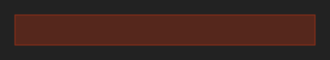


=== my_other_junction ===
bbox: ((-15.0, -1.5), (15.0, 1.5))
paths: 0
polygons: 1
  - poly(n=4)
refs: 0
props: 0
=== end ===



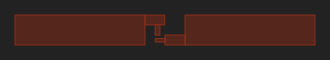


=== FakeJunction_02 ===
bbox: ((-15.0, -1.5), (15.0, 1.5))
paths: 0
polygons: 6
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
refs: 0
props: 0
=== end ===



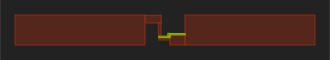


=== FakeJunction_01 ===
bbox: ((-15.0, -1.5030000000000001), (15.0, 1.5))
paths: 0
polygons: 9
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
  - poly(n=4)
refs: 0
props: 0
=== end ===



In [27]:
gds.show_imported_junction_gds()  # Shows gds.imported_junction_gds

In [28]:
# Disable cheesing output for this export.
# view_in_file controls whether cheese/no-cheese geometry appears in the GDS file.
# {1: False} = layer 1 present but suppress cheese holes from the output.
# Using Dict(main={}) triggers a warning — always specify layers explicitly.
gds.options.cheese.view_in_file = Dict(main={1: False})
gds.options.no_cheese.view_in_file = Dict(main={1: False})

In [29]:
design.renderers.gds.export_to_gds("awesome_design.gds")

10:23PM 52s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [31]:
# Load and inspect the exported GDS.
# Re-run the export cell above first if awesome_design.gds looks like an older design.
import gdstk

lib = gdstk.read_gds("awesome_design.gds")

# show=True renders the design as an embedded SVG in this cell output
# (the image saves with the notebook — no external file needed).
# scale: increase for larger chips or more detail (default 100)
# width: display width in pixels (default 800)
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)


=== GDS LIBRARY SUMMARY ===
name:      library
unit:      0.001
precision: 1e-09
cells:     7

CELLS:
  - TOP                            geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main                       geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main_1                     geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - ground_main_1                  geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - my_other_junction              geom=True bbox=((-0.015, -0.0015), (0.015, 0.0015))
  - FakeJunction_02                geom=True bbox=((-0.015, -0.0015), (0.015, 0.0015))
  - FakeJunction_01                geom=True bbox=((-0.015, -0.001503), (0.015, 0.0015))

LAYER / DATATYPE USAGE:
  layer  dtype   polys   paths
  -----  -----   -----   -----
      1      0      65       0
      1     10      24       0
      1     11      60       0
     53      0      13       0
     54      0       3       0

=== END SUMMARY ===



In [34]:
%matplotlib inline

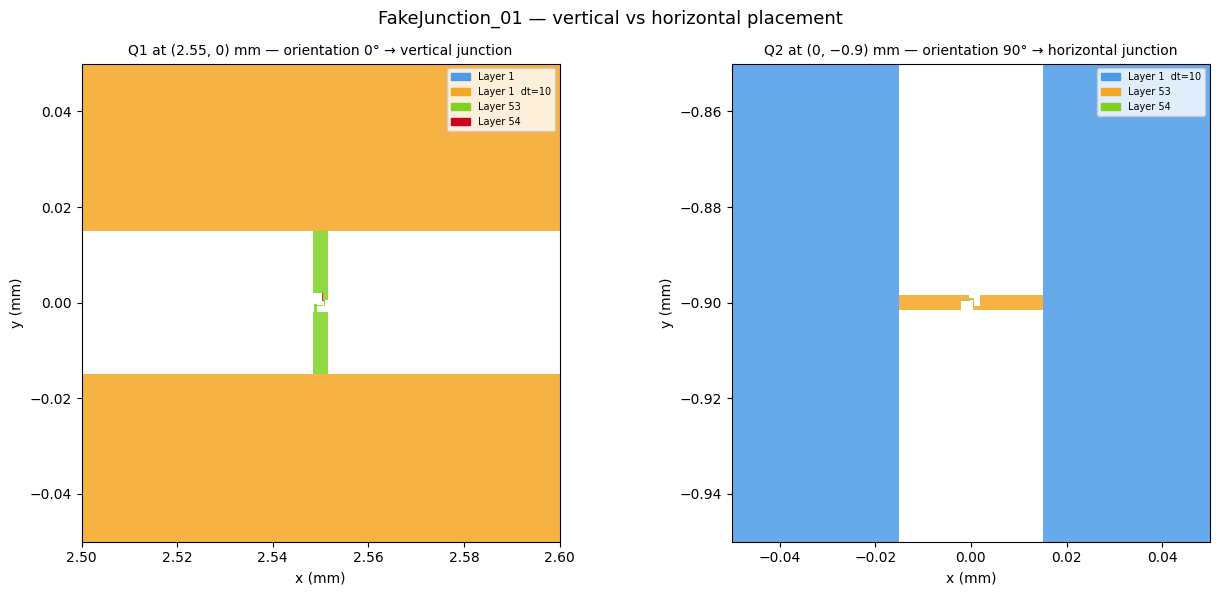

In [37]:
import matplotlib.pyplot as plt

# Q1 (orientation=0°)  → junction slot is vertical
# Q2 (orientation=90°) → junction slot is horizontal
# Both use FakeJunction_01 placed in the pocket centre.
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("FakeJunction_01 — vertical vs horizontal placement", fontsize=13)

gds.plot_gds_zoom(
    lib,
    center_mm=(2.55, 0.0),
    span_mm=0.05,
    title="Q1 at (2.55, 0) mm — orientation 0° → vertical junction",
    ax=axes[0],
)
gds.plot_gds_zoom(
    lib,
    center_mm=(0.0, -0.9),
    span_mm=0.05,
    title="Q2 at (0, −0.9) mm — orientation 90° → horizontal junction",
    ax=axes[1],
)
plt.tight_layout()
# plt.close(fig)
# display(fig)

> **Status (v0.6.x+):** The gdspy → gdstk migration is complete and validated. > Junction unit rescaling is applied automatically on import — junction cells from > any-unit GDS files (µm, nm, etc.) are scaled to the correct physical size in the > exported design. If you see junction geometry that looks too large or too small, > check that your junction GDS file's `unit` field matches its internal coordinates > (see the note above), then re-export.

## Appendix - GDS Cheesing: What It Is and How the Renderer Implements It

### what “cheesing” means in mask design

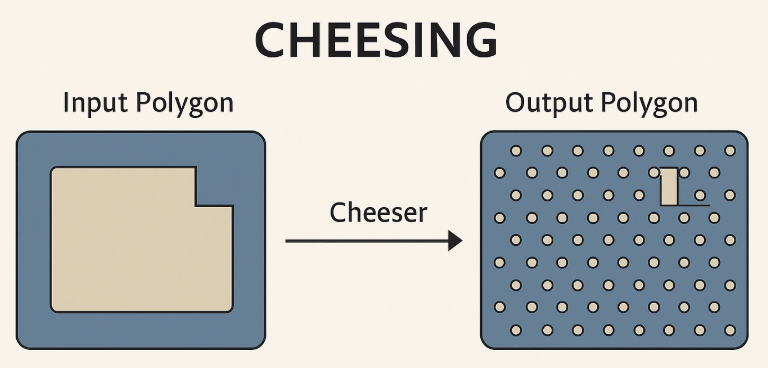

Cheesing is the practice of punching a regular pattern of small holes into large metal areas (typically the ground plane). the holes make the metal look like swiss cheese, hence the name.

cheesing reduces fabrication issues such as:

* film stress and cracking,
* charging during lithography,
* non-uniform etching,
* rule violations caused by large continuous metal regions.

small holes mitigate these problems while leaving microwave behavior essentially unchanged.

### the two components: `cheese` and `no_cheese`

cheesing relies on two option blocks in the renderer:

1. **`cheese`**: defines where holes *should* be created.
2. **`no_cheese`**: defines regions where holes are *not allowed*.

both have their own datatypes, sizes, spacing, and visibility settings:

```python
gds.options.cheese
gds.options.no_cheese
```

### how the renderer decides whether to cheese a layer

cheesing is activated only if the layer is marked in:

```python
gds.options.cheese.view_in_file[chip][layer]
gds.options.no_cheese.view_in_file[chip][layer]
```

if neither entry exists for a given layer, cheesing is skipped.

### step 1: determine ground-plane regions

before cheesing starts, the renderer constructs the metal ground plane geometry for each chip and layer:

* shapes with `subtract=True` cut holes in the ground plane,
* shapes with `subtract=False` sit on top of it.

this yields a unified understanding of the metal layout for the layer.

### step 2: generate the “no-cheese” halo

this step computes regions where holes *must not* be placed.

it works by:

* collecting all shapes that cut into the ground plane,
* converting polylines into buffered polygons when needed,
* unifying them into a single shape,
* expanding them outward using `no_cheese.buffer` to create a halo,
* clipping this halo to the chip boundary.

the resulting multipolygon forms a keep-out mask for cheesing.

### step 3: tile the chip with holes

if cheesing is enabled, the renderer lays out a hole grid across the chip:

* grid spacing is defined by `delta_x` and `delta_y`,
* hole size comes from `cheese_0_x`, `cheese_0_y` or `cheese_1_radius`,
* hole shape is rectangular or circular based on `shape`,
* holes near the chip edges (`edge_nocheese`) are removed,
* holes that fall inside “no-cheese” regions are removed.

the resulting holes are added to gds on the appropriate datatype.

### step 4: integrate holes into the final mask

cheese holes are merged differently depending on mask type:

* **positive mask**: ground plane minus holes,
* **negative mask**: inverse metal + hole logic.

this is done at the cell level so each `chip_layer` cell gets the correct geometry.

### how to disable cheesing entirely

no renderer code needs modification. simply clear the visibility settings:

```python
gds.options.cheese.view_in_file = Dict(main={})
gds.options.no_cheese.view_in_file = Dict(main={})
```

with no layers listed, cheesing logic never runs.

### summary

the renderer’s cheesing pipeline is:

1. compute the ground plane,
2. compute no-cheese keep-out zones,
3. generate holes and filter them,
4. merge into positive or negative mask.

cheesing improves manufacturability while keeping electrical performance intact, and can be turned on/off per chip and per layer via simple configuration options.

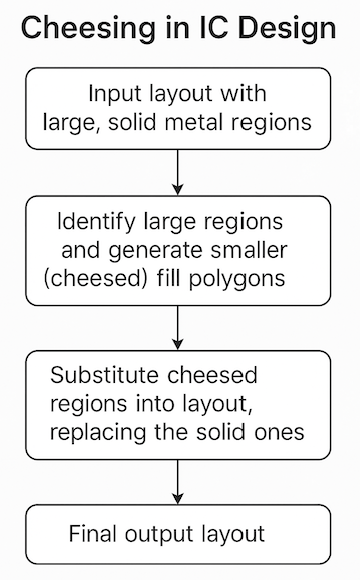

